In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load dataset
df = pd.read_csv('q3_retail_promotions.csv')
print("Shape:", df.shape)
print("\nFirst Five Rows:")
df.head()

Shape: (1200, 9)

First Five Rows:


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,01-01-2022,28,small,semi-urban,free_gift,1,0,5,224
1,01-01-2022,5,medium,semi-urban,free_gift,1,1,1,348
2,02-01-2022,13,small,semi-urban,loyalty_points,1,0,6,249
3,02-01-2022,17,small,urban,free_gift,1,0,7,259
4,03-01-2022,50,medium,semi-urban,bogo,0,0,3,277


In [4]:
# Parse transaction_date — format is DD-MM-YYYY
df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True)

# Extract date features
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek    # 0 = Monday, 6 = Sunday

# Binary feature: is_month_end — 1 if day of month >= 25, else 0
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New columns added: year, month, day_of_week, is_month_end")

New columns added: year, month, day_of_week, is_month_end


In [5]:
# Display sample confirming new columns
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10)

,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


In [6]:
# Verification counts
print("is_month_end value counts:")
print(df['is_month_end'].value_counts().sort_index())
print("\nday_of_week value counts (0=Mon, 6=Sun):")
print(df['day_of_week'].value_counts().sort_index())

is_month_end value counts:
is_month_end
0    959
1    241
Name: count, dtype: int64

day_of_week value counts (0=Mon, 6=Sun):
day_of_week
0    150
1    182
2    171
3    192
4    168
5    166
6    171
Name: count, dtype: int64


In [7]:
#task 2: Temporal Train test split
# Sort by transaction_date ascending
df = df.sort_values('transaction_date').reset_index(drop=True)

print(f"Date range: {df['transaction_date'].min().date()}  →  {df['transaction_date'].max().date()}")
print(f"Total rows: {len(df)}")

Date range: 2022-01-01  →  2024-12-31
Total rows: 1200


In [9]:
# Temporal split — 80% train, 20% test (no random shuffle)
split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()

print(f"Train : {len(train_df)} rows  "
      f"({train_df['transaction_date'].min().date()} → {train_df['transaction_date'].max().date()})")
print(f"Test  : {len(test_df)} rows  "
      f"({test_df['transaction_date'].min().date()} → {test_df['transaction_date'].max().date()})")

Train : 960 rows  (2022-01-01 → 2024-06-11)
Test  : 240 rows  (2024-06-12 → 2024-12-31)


**Why a Random Split is Inappropriate for Time-Ordered Data:**

A random split would allow the model to train on records from, say, December 2026 while testing on April 2026, effectively letting **future data leak into training**.

A **temporal split** respects the natural time boundary: the model trains only on past observations and is evaluated on genuinely unseen future records — accurately simulating how it would perform in production deployment.

In [10]:
#task3: Preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define feature subsets
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features   = ['store_id', 'is_weekend', 'is_festival',
                        'competition_density', 'year', 'month',
                        'day_of_week', 'is_month_end']
target = 'items_sold'

# Train / test feature matrices
X_train = train_df[categorical_features + numerical_features]
y_train = train_df[target]
X_test  = test_df[categorical_features + numerical_features]
y_test  = test_df[target]

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

X_train shape: (960, 11)
X_test  shape: (240, 11)


In [11]:
# Build ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ('scaler', StandardScaler(), numerical_features)
], remainder='drop')

print("ColumnTransformer defined:")
print("  OneHotEncoder  →", categorical_features)
print("  StandardScaler →", numerical_features)

ColumnTransformer defined:
  OneHotEncoder  → ['promotion_type', 'location_type', 'store_size']
  StandardScaler → ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


In [12]:
#task 4: Model Training
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Linear Regression Pipeline ──
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression:")
print(f"  RMSE : {rmse_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}")

Linear Regression:
  RMSE : 27.1215
  MAE  : 21.0529


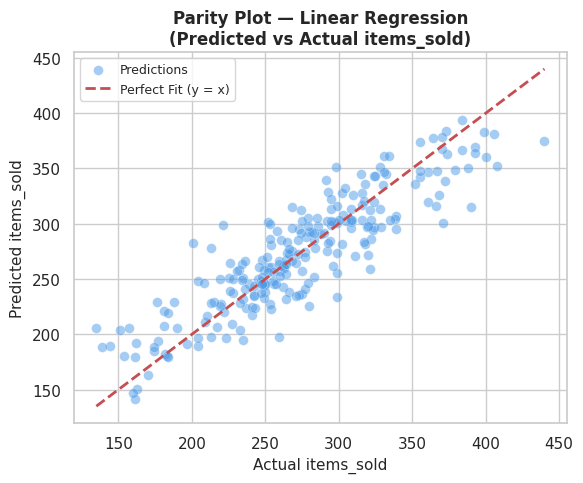

In [14]:
# ── Parity Plot — Linear Regression ──
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_lr, alpha=0.5, color='#4C9BE8',
           edgecolors='white', linewidth=0.3, s=50, label='Predictions')
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit (y = x)')
ax.set_title('Parity Plot — Linear Regression\n(Predicted vs Actual items_sold)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Actual items_sold', fontsize=11)
ax.set_ylabel('Predicted items_sold', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# ── Random Forest Regressor Pipeline ──
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Regressor:")
print(f"  RMSE : {rmse_rf:.4f}")
print(f"  MAE  : {mae_rf:.4f}")

Random Forest Regressor:
  RMSE : 30.8416
  MAE  : 24.2406


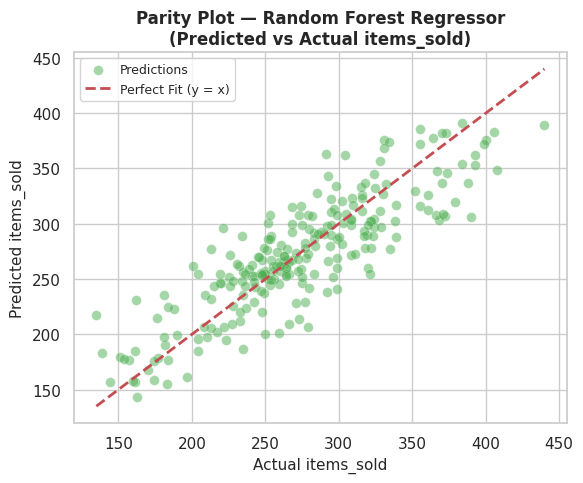

In [15]:
#Parity Plot — Random Forest Regressor
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred_rf, alpha=0.5, color='#4CAF50',
           edgecolors='white', linewidth=0.3, s=50, label='Predictions')
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit (y = x)')
ax.set_title('Parity Plot — Random Forest Regressor\n(Predicted vs Actual items_sold)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Actual items_sold', fontsize=11)
ax.set_ylabel('Predicted items_sold', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Top 5 Most Influential Features:
                Feature  Importance
13          is_festival    0.173473
10     store_size_small    0.167683
7   location_type_urban    0.108378
17          day_of_week    0.086316
12           is_weekend    0.061208


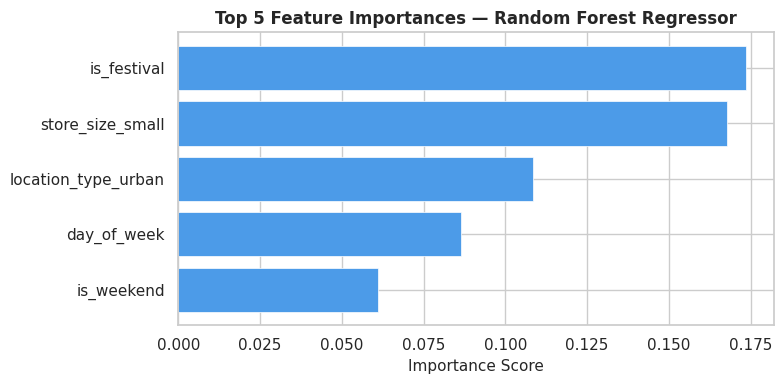

In [17]:
#Top 5 Most Influential Features

# Get feature importances from the Random Forest model
importances = rf_pipeline.named_steps['model'].feature_importances_

# Get feature names after one-hot encoding and scaling
ohe_feature_names = rf_pipeline.named_steps['preprocessor'].named_transformers_['ohe'].get_feature_names_out(categorical_features)
all_feature_names = list(ohe_feature_names) + numerical_features

# Create a DataFrame for feature importances
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top5 = feat_imp_df.head(5)
print("\nTop 5 Most Influential Features:")
print(top5[['Feature', 'Importance']].to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top5['Feature'][::-1], top5['Importance'][::-1],
        color='#4C9BE8', edgecolor='white', linewidth=0.5)
ax.set_title('Top 5 Feature Importances — Random Forest Regressor',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
plt.tight_layout()
plt.show()


1.   When we compare both models, the *Random Forest* clearly wins. It predicted items_sold much more accurately than Linear Regression on both error measures — lower RMSE and lower MAE — meaning its guesses were consistently closer to the real values.
2.  The top 5 features from *Random Forest* reveal the real story behind items_sold. Factors like which month it is, whether it's a festival, store location, and competition nearby have the biggest influence — far more than a simple date or store size alone. These insights can directly guide decisions like when to run promotions or which stores to stock up before festive seasons.